In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [39]:
CLEANED_PATH = os.path.join('..', '..', 'data', 'processed', 'go_emotions_cleaned.csv')
OUTPUT_DIR = os.path.join('..', '..', 'data', 'processed', 'hy_dp_emote')
EDA_DIR = os.path.join('..', '..', 'reports', 'eda')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(EDA_DIR, exist_ok=True)

In [40]:
df = pd.read_csv(CLEANED_PATH)
print(f"Loaded: {df.shape}")

Loaded: (57580, 32)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57580 entries, 0 to 57579
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    57580 non-null  object
 1   text                  57580 non-null  object
 2   example_very_unclear  57580 non-null  bool  
 3   admiration            57580 non-null  int64 
 4   amusement             57580 non-null  int64 
 5   anger                 57580 non-null  int64 
 6   annoyance             57580 non-null  int64 
 7   approval              57580 non-null  int64 
 8   caring                57580 non-null  int64 
 9   confusion             57580 non-null  int64 
 10  curiosity             57580 non-null  int64 
 11  desire                57580 non-null  int64 
 12  disappointment        57580 non-null  int64 
 13  disapproval           57580 non-null  int64 
 14  disgust               57580 non-null  int64 
 15  embarrassment         57580 non-null

In [42]:
df['text_len'] = df['clean_text'].str.len()

In [43]:
df.head(3)

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,clean_text,text_len
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,that game hurt.,15.0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,sexuality shouldnt be a grouping category it m...,121.0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,"you do right, if you dont care then fuck em!",44.0


In [46]:
meta_cols = {'id', 'text', 'example_very_unclear', 'clean_text', 'text_len'}
emotion_cols = [col for col in df.columns if col not in meta_cols]
print(f" Detected {len(emotion_cols)} emotion columns")

 Detected 28 emotion columns


In [47]:
for col in emotion_cols:
    # convert to numeric, fill NaN with 0, force int
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(np.int64)

In [ ]:
# Confirm all emotion columns are numeric
non_numeric_cols = [col for col in emotion_cols if not np.issubdtype(df[col].dtype, np.number)]
if non_numeric_cols:
    print(f" Still non-numeric: {non_numeric_cols}")
else:
    print(" All emotion columns are numeric")

 All emotion columns are numeric


In [52]:

df['num_labels'] = df[emotion_cols].sum(axis=1).astype(int)

print(f" {len(df):,} rows, {df['num_labels'].mean():.2f} emotions/text")

 57,580 rows, 1.19 emotions/text


Privacy Analysis

Text(0.5, 1.0, 'Privacy Masks')

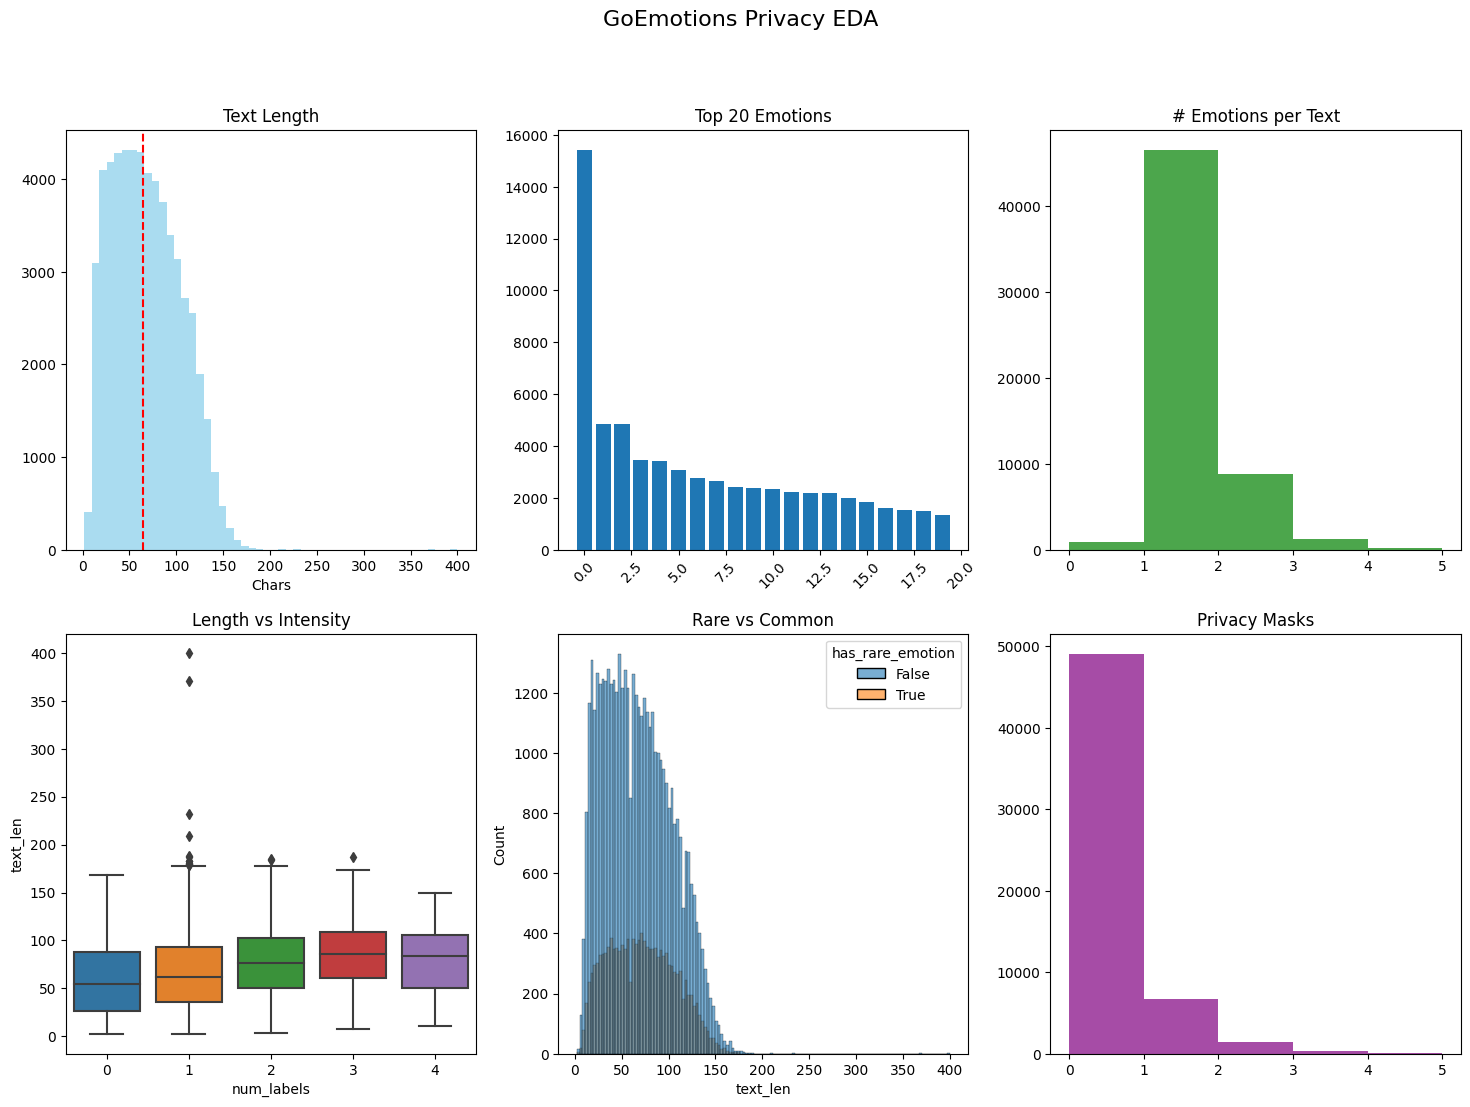

In [ ]:
xx

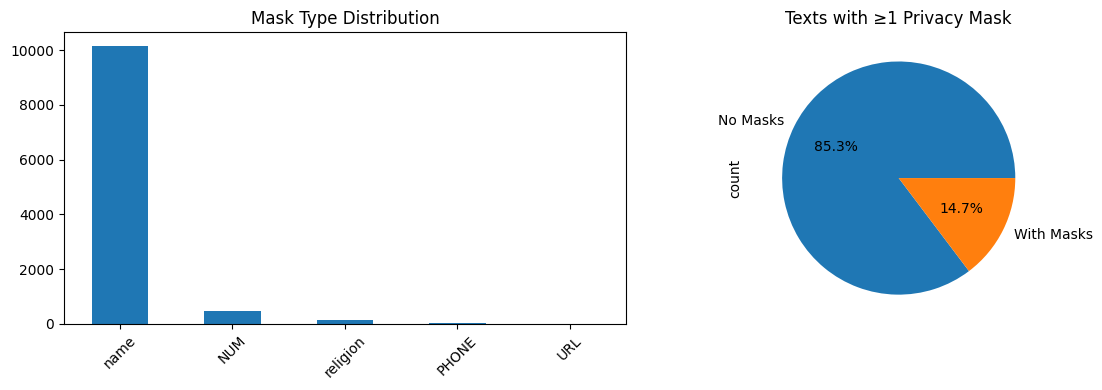

Mask coverage: 14.7%
Total masks found: 10782.0


In [58]:
# PRIVACY MASK COVERAGE (RQ1/RQ2)
mask_regex = r'\[(?i)(name|religion|user|phone|email|url|num|location|health_prof|health_term|med|condition|self_harm|addiction|date|age_time|year|family|friend|money|org|legal)\]'
df['mask_types'] = df['clean_text'].str.findall(mask_regex)
df['mask_count'] = df['mask_types'].str.len()


# Filter out empty lists before concatenating
mask_lists = df['mask_types'].dropna()
mask_lists = mask_lists[mask_lists.str.len() > 0]  # Only non-empty lists

if len(mask_lists) > 0:
    mask_dist = pd.Series(np.concatenate(mask_lists.tolist())).value_counts()
else:
    mask_dist = pd.Series(dtype=int)  # Empty series if no masks found

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

if len(mask_dist) > 0:
    mask_dist.head(8).plot(kind='bar', ax=ax1)
    ax1.set_title('Mask Type Distribution')
else:
    ax1.text(0.5, 0.5, 'No masks found', ha='center', va='center')
    ax1.set_title('Mask Type Distribution')
    
ax1.tick_params(axis='x', rotation=45)

(df['mask_count'] > 0).value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%', labels=['No Masks', 'With Masks'])
ax2.set_title('Texts with ≥1 Privacy Mask')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/privacy_masks.png')
plt.show()
print(f"Mask coverage: {df['mask_count'].gt(0).mean():.1%}")
print(f"Total masks found: {df['mask_count'].sum()}")

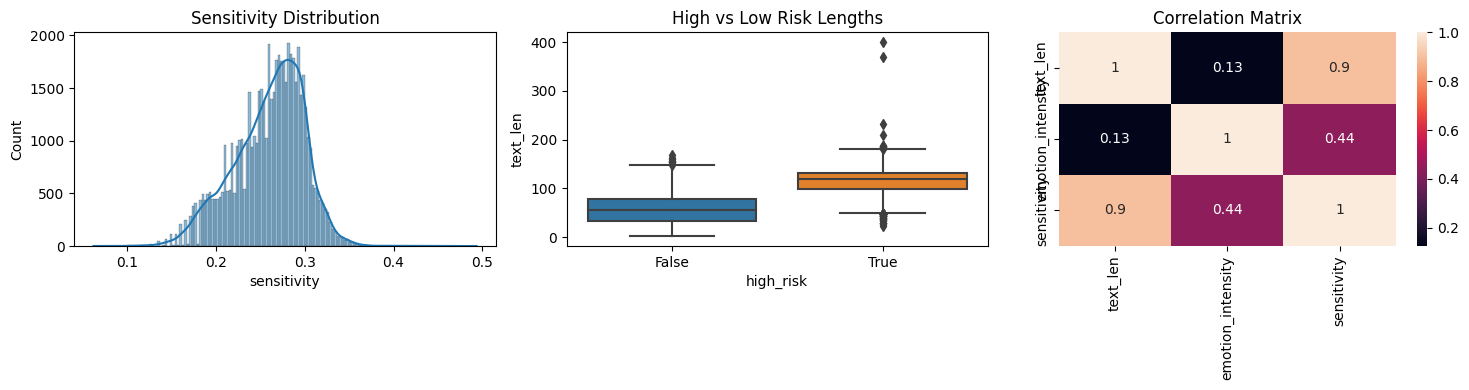

High-risk texts: 19.7%


In [60]:
# RQ4 Sensitivity computation
# Exclude all non-emotion columns (including derived features)
exclude_cols = {
    'id', 'text', 'example_very_unclear', 'clean_text', 'text_len',
    'num_labels', 'has_rare_emotion', 'mask_count', 'mask_types',
    'mask_phone', 'mask_email', 'mask_url', 'mask_ssn', 'mask_zip',
    'mask_date', 'mask_age', 'advanced_mask_count'
}
emotion_cols = [col for col in df.columns if col not in exclude_cols]

# Ensure all emotion columns are numeric
emotion_cols = [col for col in emotion_cols if np.issubdtype(df[col].dtype, np.number)]

df['emotion_intensity'] = df[emotion_cols].sum(axis=1) / len(emotion_cols)
df['sensitivity'] = 0.7 * df['emotion_intensity'] + 0.3 * (np.log1p(df['text_len']) / np.log1p(200))
df['high_risk'] = df['sensitivity'] > df['sensitivity'].quantile(0.8)

# Plot sensitivity heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['sensitivity'], kde=True, ax=axes[0])
axes[0].set_title('Sensitivity Distribution')

sns.boxplot(data=df, x='high_risk', y='text_len', ax=axes[1])
axes[1].set_title('High vs Low Risk Lengths')

sns.heatmap(df[['text_len', 'emotion_intensity', 'sensitivity']].corr(), annot=True, ax=axes[2])
axes[2].set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig(f'{EDA_DIR}/sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"High-risk texts: {df['high_risk'].mean():.1%}")

In [67]:
high_risk_coverage = df[df['high_risk']]['mask_count'].gt(0).mean()
print(f"High-risk texts masked: {high_risk_coverage:.1%} vs overall 14.7%")

High-risk texts masked: 17.6% vs overall 14.7%


Emotion Analysis

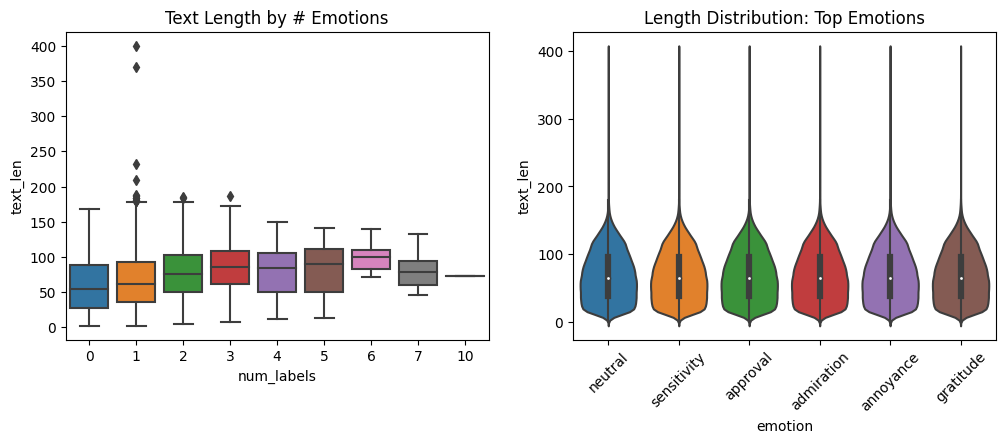

In [ ]:
# Length vs Emotion Intensity 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='num_labels', y='text_len', ax=axes[0])
axes[0].set_title('Text Length by # Emotions')

top_emotions = df[emotion_cols].sum().nlargest(6).index
sns.violinplot(data=df.melt(id_vars='text_len', value_vars=top_emotions, var_name='emotion', value_name='label'), 
               x='emotion', y='text_len', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Length Distribution: Top Emotions')
plt.savefig(f'{EDA_DIR}/length_emotion.png')
plt.show()

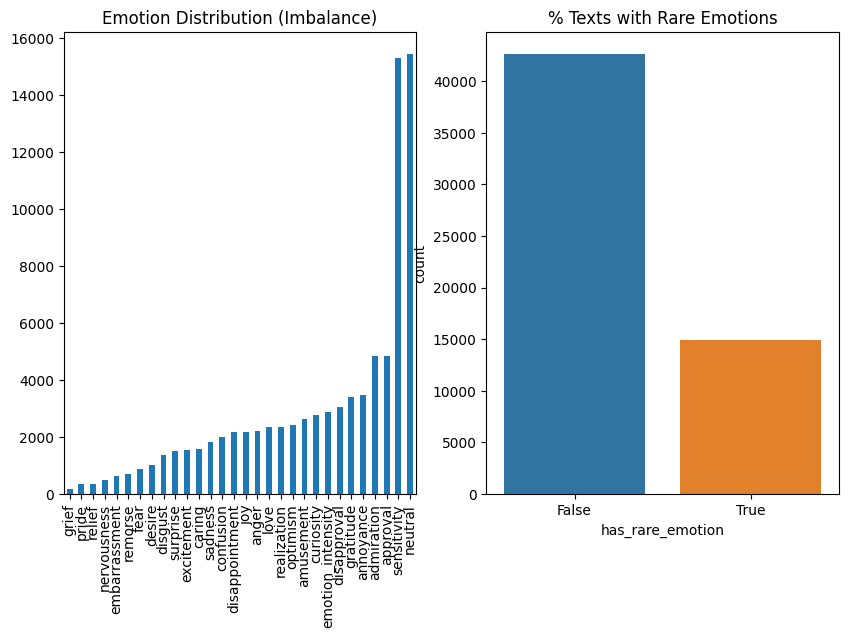

Rare emotion texts: 26.0%


In [ ]:
# Emotion imbalance 
emotion_sums = df[emotion_cols].sum().sort_values()
rare_emotions = emotion_sums[emotion_sums < emotion_sums.median()].index
df['has_rare_emotion'] = df[rare_emotions].any(axis=1)

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
emotion_sums.plot(kind='bar')
plt.title('Emotion Distribution (Imbalance)'); plt.xticks(rotation=90)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='has_rare_emotion')
plt.title('% Texts with Rare Emotions')
plt.savefig(f'{EDA_DIR}/imbalance.png')
plt.show()
print(f"Rare emotion texts: {df['has_rare_emotion'].mean():.1%}")


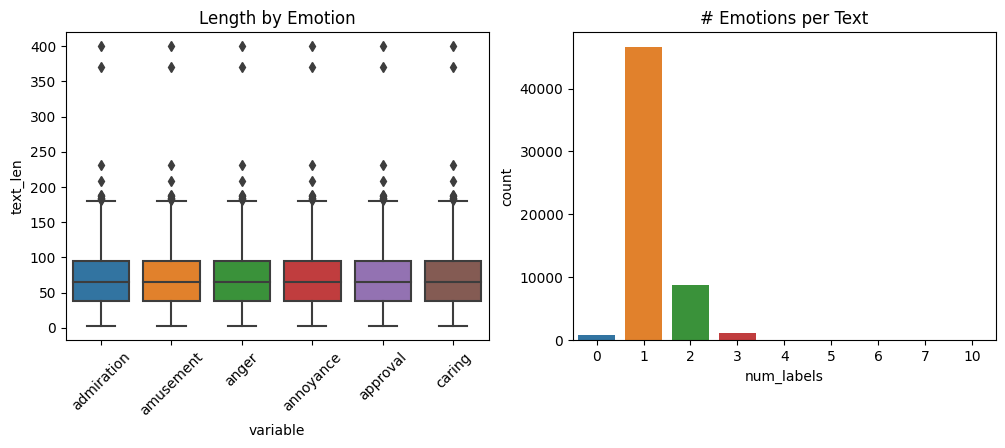

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df.melt(id_vars='text_len', value_vars=emotion_cols[:6]), 
            x='variable', y='text_len', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45); axes[0].set_title('Length by Emotion')

sns.countplot(data=df, x='num_labels', ax=axes[1])
axes[1].set_title('# Emotions per Text'); 

Sensitivity Stratification

High-risk: 19.7% | Sensitivity std: 0.039


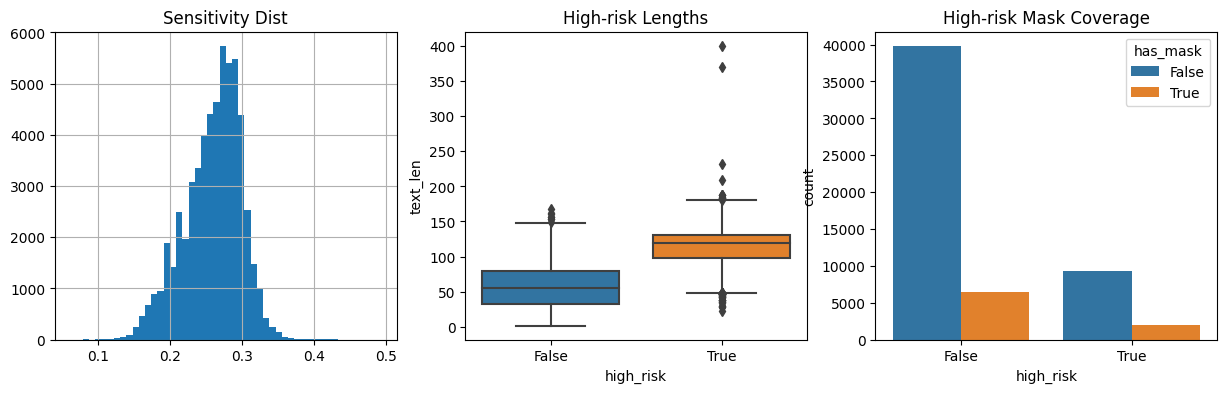

In [ ]:
df['has_mask'] = df['mask_count'].gt(0)

# SENSITIVITY VALIDATION
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['sensitivity'].hist(ax=axes[0], bins=50); axes[0].set_title('Sensitivity Dist')
sns.boxplot(data=df, x='high_risk', y='text_len', ax=axes[1]); axes[1].set_title('High-risk Lengths')

sns.countplot(data=df, x='high_risk', hue='has_mask', ax=axes[2])
axes[2].set_title('High-risk Mask Coverage'); plt.savefig(f'{EDA_DIR}/sensitivity.png')

print(f"High-risk: {df['high_risk'].mean():.1%} | Sensitivity std: {df['sensitivity'].std():.3f}")

Handle outliers

In [ ]:
# Create tokens if missing
if 'tokens' not in df.columns:
    df['tokens'] = df['clean_text'].str.split().str.len()

df['len_z'] = (df['text_len'] - df['text_len'].mean()) / df['text_len'].std()
df['token_z'] = (df['tokens'] - df['tokens'].mean()) / df['tokens'].std()
df['emo_z'] = (df['num_labels'] - df['num_labels'].mean()) / df['num_labels'].std()

# Combined outlier score (Mahalanobis distance proxy)
df['outlier_score'] = np.sqrt(df[['len_z', 'token_z', 'emo_z']].pow(2).sum(axis=1))
outlier_threshold = df['outlier_score'].quantile(0.99)  # Top 1%

df['is_outlier'] = df['outlier_score'] > outlier_threshold
print(f"Outliers detected: {df['is_outlier'].mean():.1%} ({df['is_outlier'].sum()} samples)")

Outliers detected: 1.0% (576 samples)


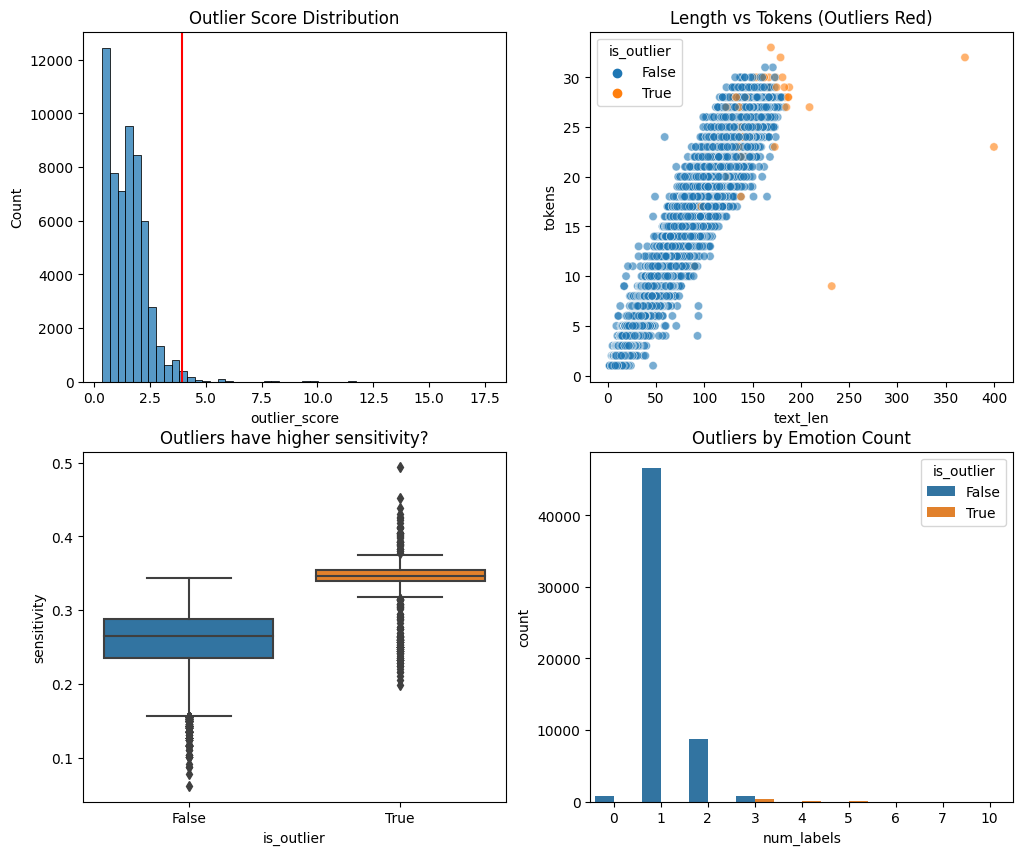

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df['outlier_score'], bins=50, ax=axes[0,0]); axes[0,0].axvline(outlier_threshold, color='r')
axes[0,0].set_title('Outlier Score Distribution')

sns.scatterplot(data=df, x='text_len', y='tokens', hue='is_outlier', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('Length vs Tokens (Outliers Red)')

sns.boxplot(data=df, x='is_outlier', y='sensitivity', ax=axes[1,0])
axes[1,0].set_title('Outliers have higher sensitivity?')

sns.countplot(data=df, x='num_labels', hue='is_outlier', ax=axes[1,1])
axes[1,1].set_title('Outliers by Emotion Count')
plt.show()